<a href="https://colab.research.google.com/github/chayansaha2/Internship_Project_Task/blob/main/cognify_internship_project_task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK-01**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset cognify.csv to Dataset cognify.csv


--- Task 1: Regression Analysis ---
MSE: 0.1340
R2 Score: 0.9411


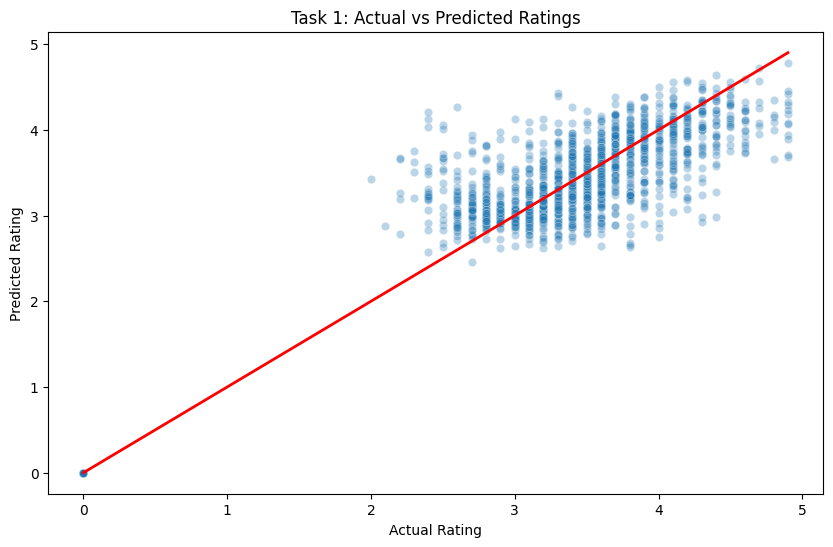

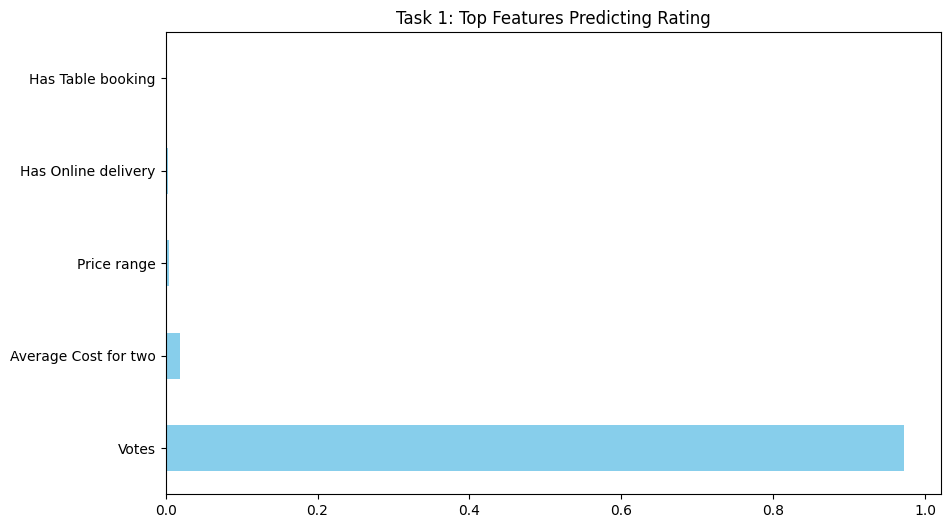

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

# Load the dataset
df = pd.read_csv('Dataset cognify.csv')

# --- DATA PREPROCESSING ---
# Handle missing values
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

# Encode categorical variables for Machine Learning
le = LabelEncoder()
df['Has Table booking'] = le.fit_transform(df['Has Table booking'])
df['Has Online delivery'] = le.fit_transform(df['Has Online delivery'])

# Prepare for Task 3: Simplify Cuisines to just the primary one
df['Primary Cuisine'] = df['Cuisines'].apply(lambda x: x.split(',')[0])

# TASK 1: Predict Restaurant Ratings (Regression)

print("--- Task 1: Regression Analysis ---")
X1 = df[['Average Cost for two', 'Price range', 'Votes', 'Has Table booking', 'Has Online delivery']]
y1 = df['Aggregate rating']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X1_train, y1_train)
y1_pred = regressor.predict(X1_test)

print(f"MSE: {mean_squared_error(y1_test, y1_pred):.4f}")
print(f"R2 Score: {r2_score(y1_test, y1_pred):.4f}")

# Visualization 1: Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y1_test, y=y1_pred, alpha=0.3)
plt.plot([y1.min(), y1.max()], [y1.min(), y1.max()], color='red', lw=2)
plt.title('Task 1: Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.show()

# Visualization 2: Feature Importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(regressor.feature_importances_, index=X1.columns)
feat_importances.nlargest(5).plot(kind='barh', color='skyblue')
plt.title('Task 1: Top Features Predicting Rating')
plt.show()

